In [1]:
%load_ext autoreload
%autoreload 2
import helper_functions as hf
from imports import *
import importlib

num_available_cpus = multiprocessing.cpu_count()
print("Number of available CPUs:", num_available_cpus)

torch.cuda.empty_cache()
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device =", device)
torch.set_default_tensor_type('torch.cuda.FloatTensor') if torch.cuda.is_available() else print ('cpu')

torch.set_num_threads(num_available_cpus)

print("Number of threads:", torch.get_num_threads())
print("Number of interop threads:", torch.get_num_interop_threads())

/nobackup/users/sambt/anaconda3/envs/quak/lib/python3.7/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Number of available CPUs: 80
Device = cuda:0
Number of threads: 80
Number of interop threads: 80


# Function to construct quak spaces

In [4]:
def makeQuakSpace(bkg_axes,sig_axes,baseDir):
    from sklearn.decomposition import PCA
    
    axes = sig_axes+bkg_axes
    spaceName = "-".join(bkg_axes+sig_axes)
    if not os.path.isdir(baseDir+"/quakSpacesNoPCA/"+spaceName):
        os.mkdir(baseDir+"/quakSpacesNoPCA/"+spaceName)
    outDir = baseDir+"/quakSpacesNoPCA/"+spaceName+"/"
    
    # make outputs for the files
    for file in [ff for ff in os.listdir(baseDir+"/nominal/") if ".h5" in ff]:
        fName = baseDir+"/nominal/"+file
        with h5py.File(fName,"r") as f:
            mass = f["mass"][()]
            with h5py.File(outDir+file,"w") as of:
                of.create_dataset("mass",data=mass)
                for i in range(len(axes)):
                    of.create_dataset(axes[i],data=f[axes[i]][()])
    return outDir

In [123]:
import corner
import matplotlib.lines as mlines
import matplotlib as mpl
def makeCornerPlots(directory,bkg_axes,sig_axes,sigs,nBins=50,lossCut=100,quantile=0.01):
    axes = bkg_axes+sig_axes
    bkg_data = []
    for i in range(3):
        with h5py.File(outDir+"eval_QCDBKG_{0}.h5".format(i),"r") as f:
            data = []
            for ax in axes:
                data.append(f[ax][()][:,np.newaxis])
            data = np.concatenate(data,axis=1)
            data = data[np.all(np.abs(data) < lossCut,axis=1)]
            bkg_data.append(data)
    bkg_data = np.concatenate(bkg_data,axis=0)
    
    sig_data = []
    for sig in sigs:
        with h5py.File(outDir+"eval_{0}.h5".format(sig),"r") as f:
            data = []
            for ax in axes:
                data.append(f[ax][()][:,np.newaxis])
            data = np.concatenate(data,axis=1)
            data = data[np.all(np.abs(data) < lossCut,axis=1)]
            sig_data.append(data)
    
    datas = [bkg_data] + sig_data
    leftLims, rightLims = [],[]
    for dat in datas:
        leftLims.append(np.quantile(dat,quantile/2,axis=0).reshape(1,-1))
        rightLims.append(np.quantile(dat,1-quantile/2,axis=0).reshape(1,-1))
    leftLims = np.concatenate(leftLims,axis=0)
    rightLims = np.concatenate(rightLims,axis=0)
    leftLims = np.min(leftLims,axis=0)
    rightLims = np.max(rightLims,axis=0)
    lossRanges = [[leftLims[i],rightLims[i]] for i in range(len(leftLims))]
    print(lossRanges)
    labels = ["QCDBKG"] + sigs
    fig = plt.figure(figsize=(10,10))
    lines = []
    for i,d in enumerate(datas):
        b = corner.corner(
            datas[i],
            quantiles=[0.99],
            fig=fig,
            color='C{0}'.format(i),
            hist_kwargs={'density':True},
            contour_kwargs={"levels":[20]},
            labels=axes,
            label_kwargs={'fontsize':14},
            bins=[nBins for i in range(len(axes))],
            plot_datapoints=False,
            plot_density=True,
            fill_contours=False,
            no_fill_contours=True,
            range=lossRanges,
            data_kwargs={"alpha":0.5}
        )
        lines.append(mlines.Line2D([], [], color='C{0}'.format(i), label=labels[i]))
    plt.legend(handles=lines,loc=4,bbox_to_anchor=(0., 1.0, 1., .0))

# Making dataSB-training quak spaces (2017)

In [124]:
year = 2017
baseDir="evaluations/dataSB/{0}".format(year)
Path(baseDir+"/quakSpacesNoPCA").mkdir(exist_ok=True)

[[1.271911334991455, 52.263453006744385], [4.4398034477233885, 89.92247200012207]]


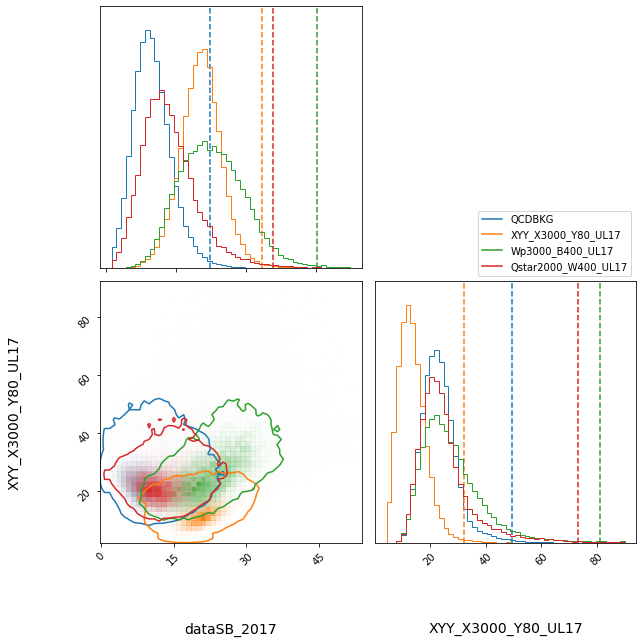

In [125]:
sig_axes = ['XYY_X3000_Y80_UL17']
bkg_axes = ['dataSB_{0}'.format(year)]
sigs = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
outDir = makeQuakSpace(bkg_axes,sig_axes,baseDir)
makeCornerPlots(outDir,bkg_axes,sig_axes,sigs)

[[1.2699153375625611, 69.14971771240255], [9.891252632141114, 91.88630958557125]]


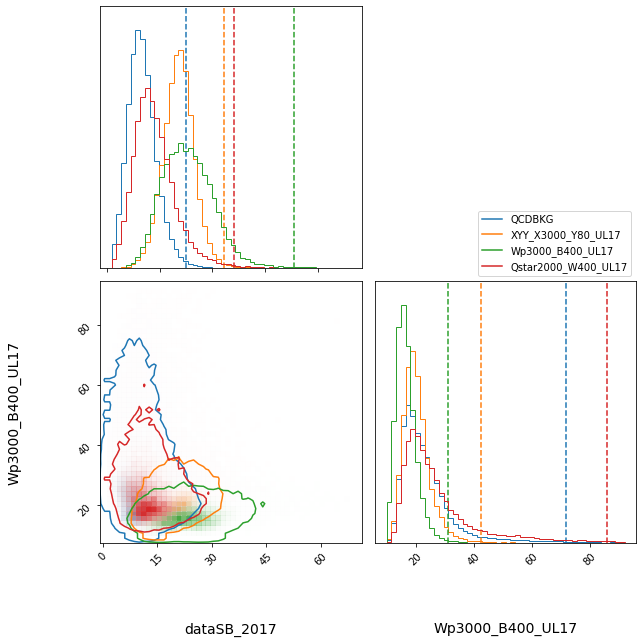

In [126]:
sig_axes = ['Wp3000_B400_UL17']
bkg_axes = ['dataSB_{0}'.format(year)]
sigs = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
outDir = makeQuakSpace(bkg_axes,sig_axes,baseDir)
makeCornerPlots(outDir,bkg_axes,sig_axes,sigs)

[[1.274423980712891, 64.43579578399559], [7.840040426254273, 60.00186948776179]]


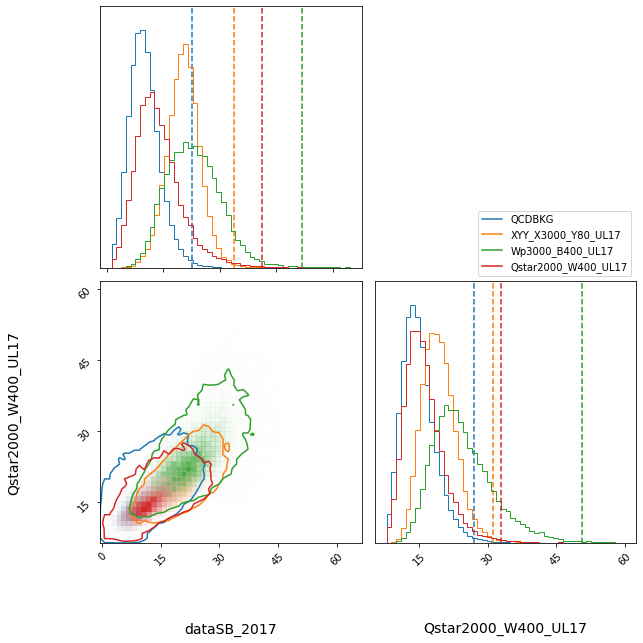

In [127]:
sig_axes = ['Qstar2000_W400_UL17']
bkg_axes = ['dataSB_{0}'.format(year)]
sigs = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
outDir = makeQuakSpace(bkg_axes,sig_axes,baseDir)
makeCornerPlots(outDir,bkg_axes,sig_axes,sigs)

[[1.2697315454483031, 52.25108983993535], [4.439175863265991, 89.8278648376465], [9.867657203674316, 91.51692466735845]]


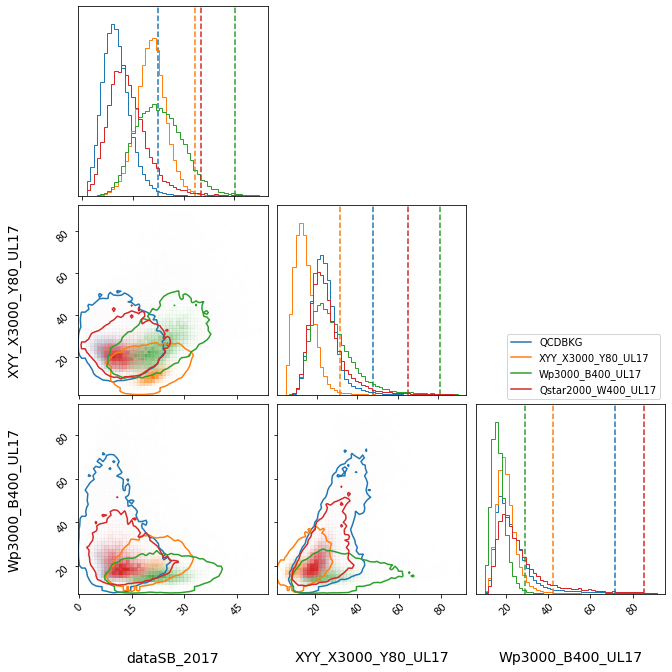

In [128]:
sig_axes = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17']
bkg_axes = ['dataSB_{0}'.format(year)]
sigs = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
outDir = makeQuakSpace(bkg_axes,sig_axes,baseDir)
makeCornerPlots(outDir,bkg_axes,sig_axes,sigs)

[[1.271911334991455, 52.263453006744385], [4.4397906398773195, 89.92247200012207], [7.838635087013245, 50.73800468444824]]


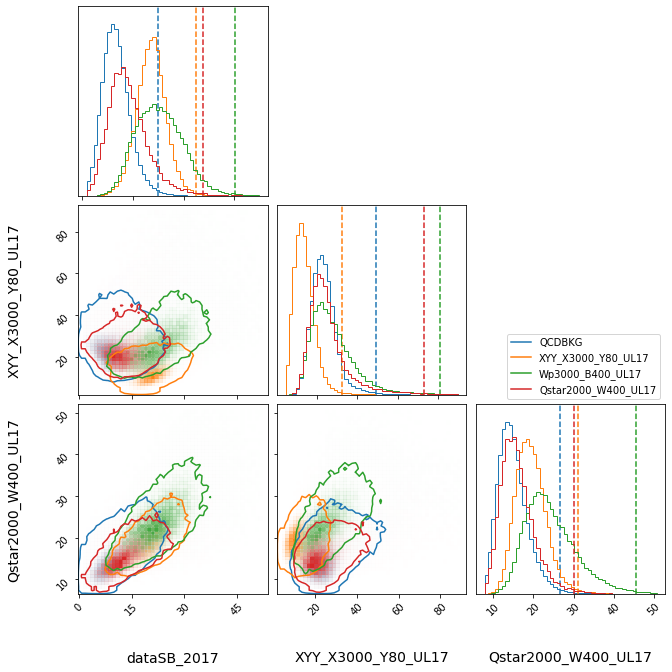

In [129]:
sig_axes = ['XYY_X3000_Y80_UL17','Qstar2000_W400_UL17']
bkg_axes = ['dataSB_{0}'.format(year)]
sigs = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
outDir = makeQuakSpace(bkg_axes,sig_axes,baseDir)
makeCornerPlots(outDir,bkg_axes,sig_axes,sigs)

[[1.2699153375625611, 64.41391220092771], [9.890814223289489, 91.88630958557125], [7.835795006752014, 60.00362215042084]]


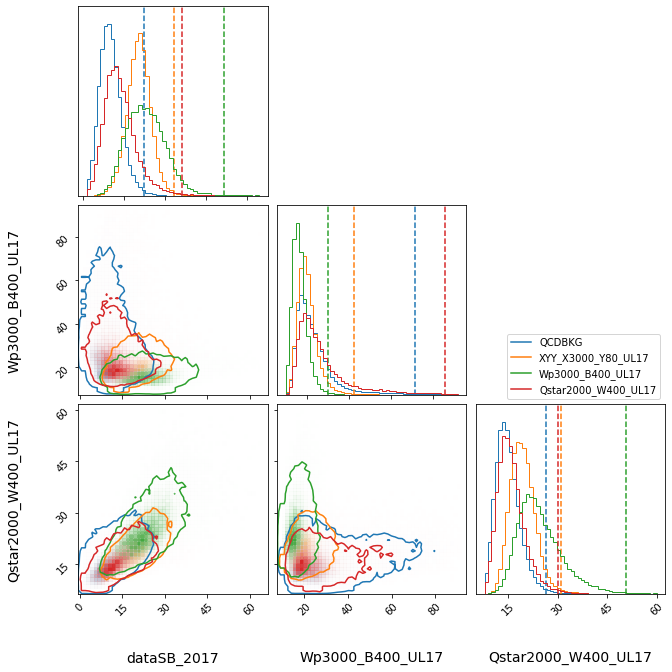

In [130]:
sig_axes = ['Wp3000_B400_UL17','Qstar2000_W400_UL17']
bkg_axes = ['dataSB_{0}'.format(year)]
sigs = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
outDir = makeQuakSpace(bkg_axes,sig_axes,baseDir)
makeCornerPlots(outDir,bkg_axes,sig_axes,sigs)

[[1.2697315454483031, 52.25108983993535], [4.439163055419922, 89.8278648376465], [9.867657203674316, 91.51692466735845], [7.835418558120727, 50.73820564270024]]


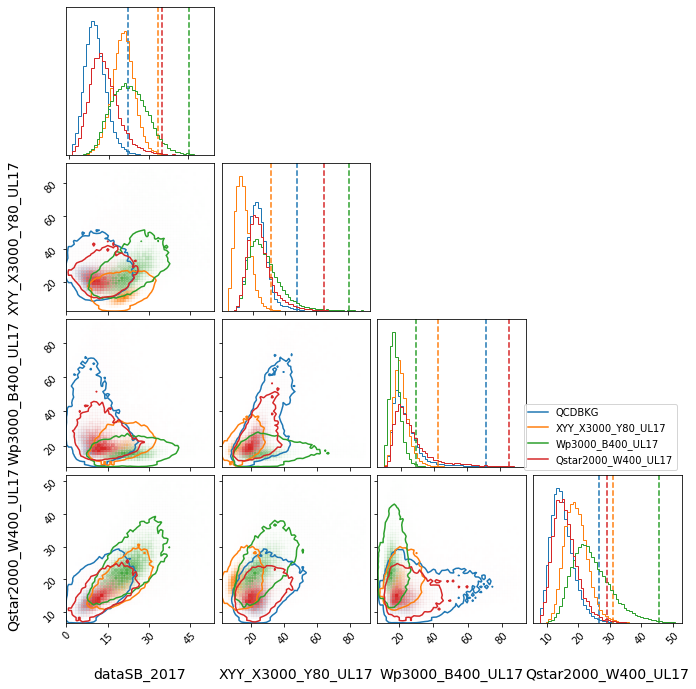

In [131]:
sig_axes = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
bkg_axes = ['dataSB_{0}'.format(year)]
sigs = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
outDir = makeQuakSpace(bkg_axes,sig_axes,baseDir)
makeCornerPlots(outDir,bkg_axes,sig_axes,sigs)

# Making QCDBKG (MC) quak spaces

In [132]:
year = 2017
baseDir="evaluations/qcdbkg/{0}".format(year)
Path(baseDir+"/quakSpacesNoPCA").mkdir(exist_ok=True)

[[0.4965266036987305, 56.437691268920474], [2.4914687252044683, 89.10206047058085]]


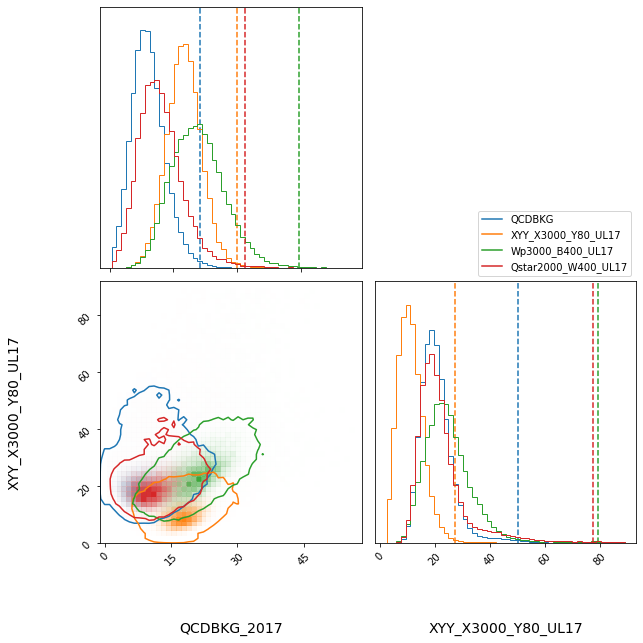

In [133]:
sig_axes = ['XYY_X3000_Y80_UL17']
bkg_axes = ['QCDBKG_{0}'.format(year)]
sigs = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
outDir = makeQuakSpace(bkg_axes,sig_axes,baseDir)
makeCornerPlots(outDir,bkg_axes,sig_axes,sigs)

[[0.49363840103149415, 67.60754661560023], [9.647575073242187, 92.7233824157715]]


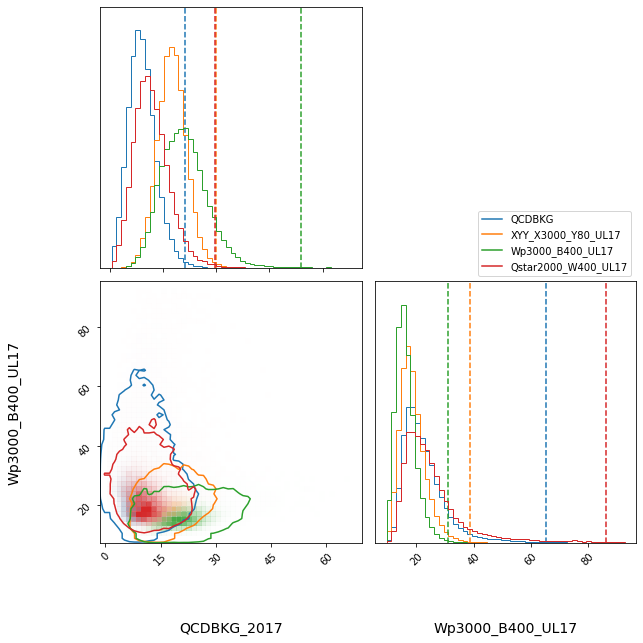

In [134]:
sig_axes = ['Wp3000_B400_UL17']
bkg_axes = ['QCDBKG_{0}'.format(year)]
sigs = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
outDir = makeQuakSpace(bkg_axes,sig_axes,baseDir)
makeCornerPlots(outDir,bkg_axes,sig_axes,sigs)

[[0.49683304786682125, 64.39380584716791], [7.044896879196167, 71.79835205078123]]


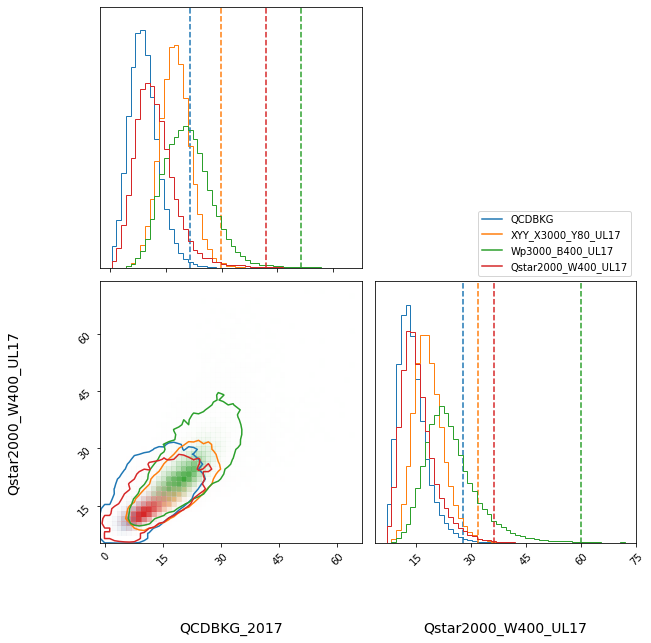

In [135]:
sig_axes = ['Qstar2000_W400_UL17']
bkg_axes = ['QCDBKG_{0}'.format(year)]
sigs = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
outDir = makeQuakSpace(bkg_axes,sig_axes,baseDir)
makeCornerPlots(outDir,bkg_axes,sig_axes,sigs)

[[0.4936335611343384, 56.31564369201649], [2.486399030685425, 89.04364608764634], [9.640429601669311, 92.3948110961914]]


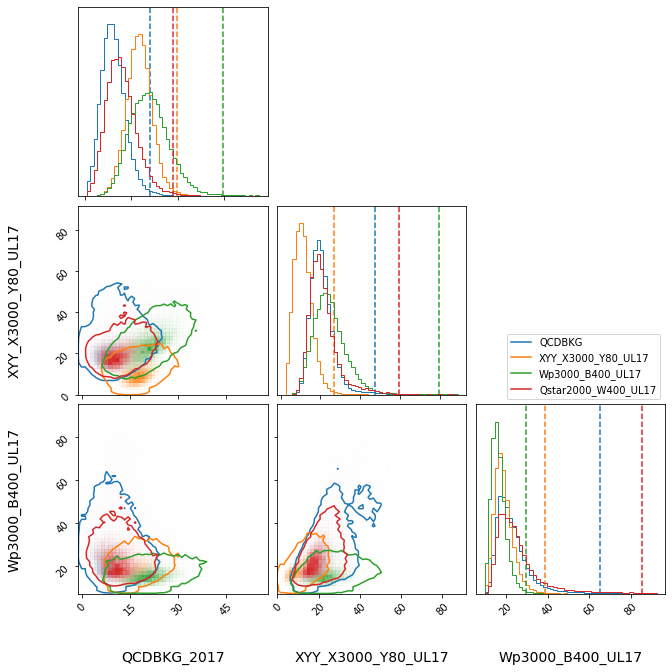

In [136]:
sig_axes = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17']
bkg_axes = ['QCDBKG_{0}'.format(year)]
sigs = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
outDir = makeQuakSpace(bkg_axes,sig_axes,baseDir)
makeCornerPlots(outDir,bkg_axes,sig_axes,sigs)

[[0.49652630329132075, 56.093548717498706], [2.491371231079102, 88.82174613952634], [7.044504098892212, 63.274728279113745]]


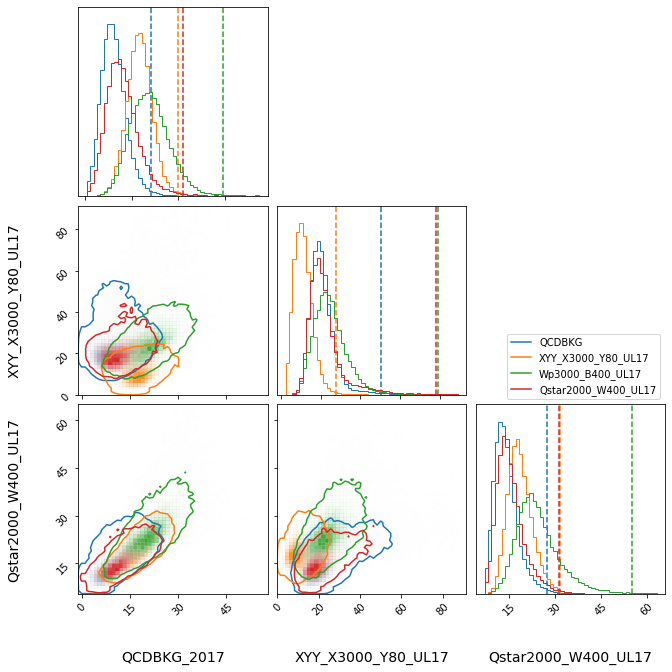

In [137]:
sig_axes = ['XYY_X3000_Y80_UL17','Qstar2000_W400_UL17']
bkg_axes = ['QCDBKG_{0}'.format(year)]
sigs = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
outDir = makeQuakSpace(bkg_axes,sig_axes,baseDir)
makeCornerPlots(outDir,bkg_axes,sig_axes,sigs)

[[0.4936379861831665, 64.39687355041487], [9.645973281860352, 92.72351436614991], [7.042129731178283, 71.79949417114251]]


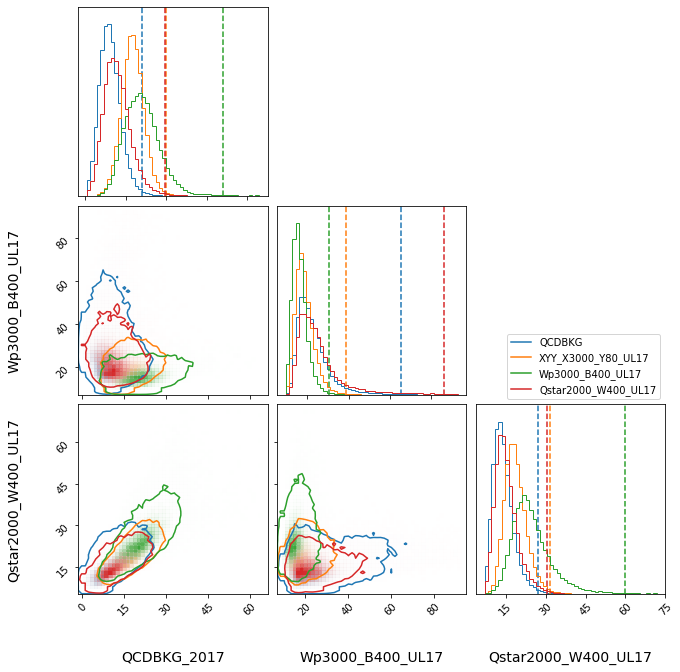

In [138]:
sig_axes = ['Wp3000_B400_UL17','Qstar2000_W400_UL17']
bkg_axes = ['QCDBKG_{0}'.format(year)]
sigs = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
outDir = makeQuakSpace(bkg_axes,sig_axes,baseDir)
makeCornerPlots(outDir,bkg_axes,sig_axes,sigs)

[[0.49363342285156253, 55.974026451110696], [2.4863015365600587, 88.8052015686035], [9.640319795608521, 92.39498649597172], [7.042122650146484, 63.27521797180172]]


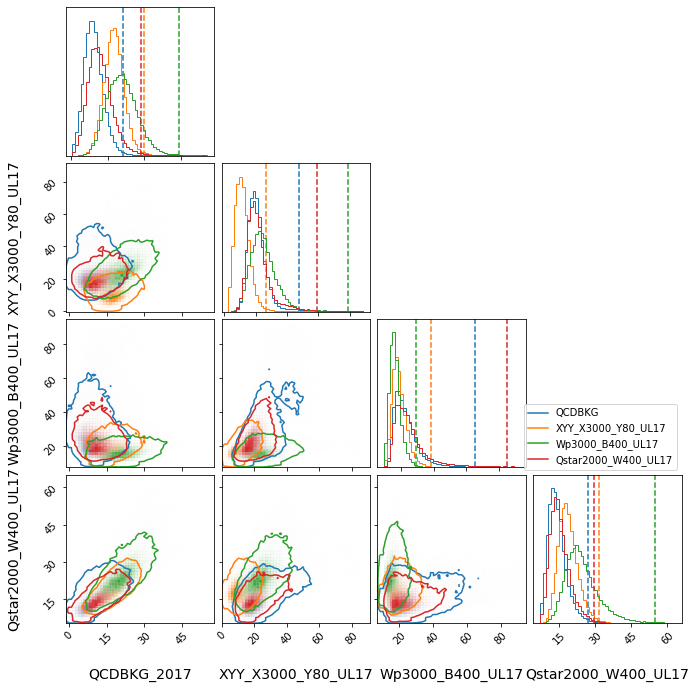

In [139]:
sig_axes = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
bkg_axes = ['QCDBKG_{0}'.format(year)]
sigs = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
outDir = makeQuakSpace(bkg_axes,sig_axes,baseDir)
makeCornerPlots(outDir,bkg_axes,sig_axes,sigs)

# Minor backgrounds

In [140]:
year = 2017
baseDir="evaluations/qcdbkg/{0}".format(year)
Path(baseDir+'/quakSpacesNoPCA').mkdir(exist_ok=True)

[[0.7020202827453614, 42.252727355957035], [9.518882551193238, 75.54198303222623], [2.666613802909851, 40.120452880858934], [2.4903962898254397, 88.77872253417992]]


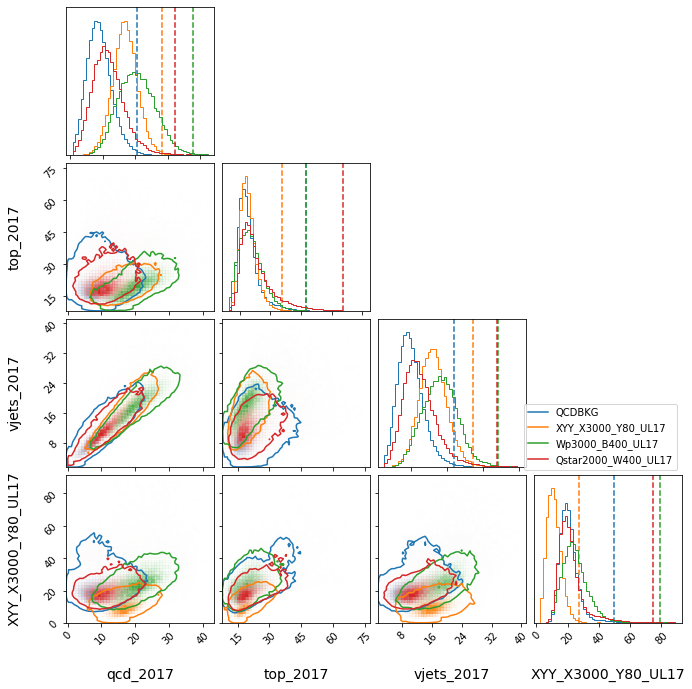

In [141]:
sig_axes = ['XYY_X3000_Y80_UL17']
bkg_axes = ['qcd_{0}'.format(year),'top_{0}'.format(year),'vjets_{0}'.format(year)]
sigs = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
outDir = makeQuakSpace(bkg_axes,sig_axes,baseDir)
makeCornerPlots(outDir,bkg_axes,sig_axes,sigs)

[[0.7001232624053955, 49.48701095581043], [9.533743286132813, 76.43709869384676], [2.663517580032349, 46.5524639129635], [9.64648208618164, 92.47215690612796]]


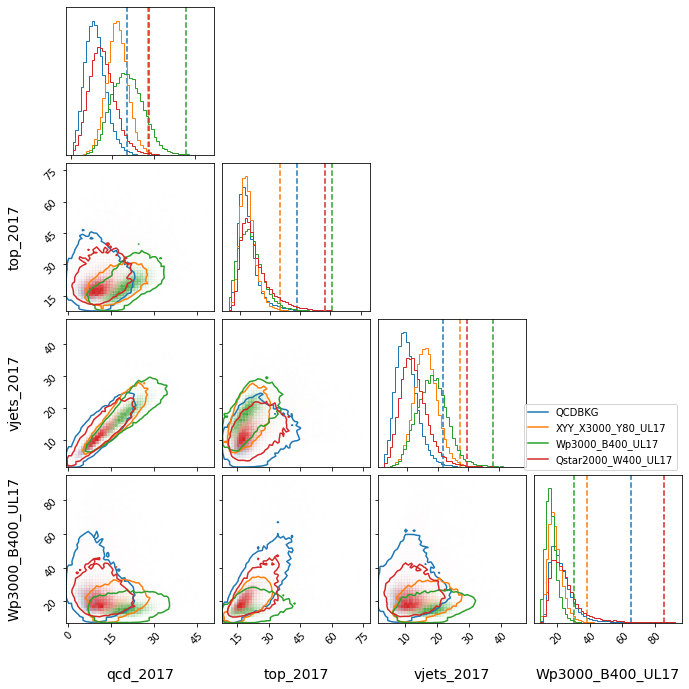

In [142]:
sig_axes = ['Wp3000_B400_UL17']
bkg_axes = ['qcd_{0}'.format(year),'top_{0}'.format(year),'vjets_{0}'.format(year)]
sigs = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
outDir = makeQuakSpace(bkg_axes,sig_axes,baseDir)
makeCornerPlots(outDir,bkg_axes,sig_axes,sigs)

[[0.7021242904663086, 48.462770252227855], [9.533363609313966, 83.85201267242493], [2.668114938735962, 48.44170127868681], [7.044667072296143, 69.50917476654038]]


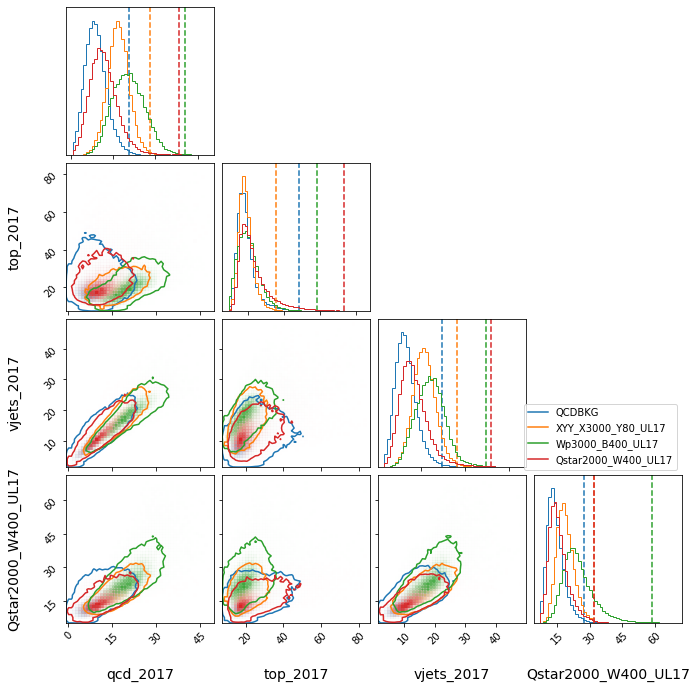

In [143]:
sig_axes = ['Qstar2000_W400_UL17']
bkg_axes = ['qcd_{0}'.format(year),'top_{0}'.format(year),'vjets_{0}'.format(year)]
sigs = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
outDir = makeQuakSpace(bkg_axes,sig_axes,baseDir)
makeCornerPlots(outDir,bkg_axes,sig_axes,sigs)

[[0.6999011993408202, 42.24777313232423], [9.518743891716005, 62.7543669891357], [2.66337619304657, 38.22708110809327], [2.485619077682495, 88.57913715362554], [9.640338120460509, 92.13078609466552]]


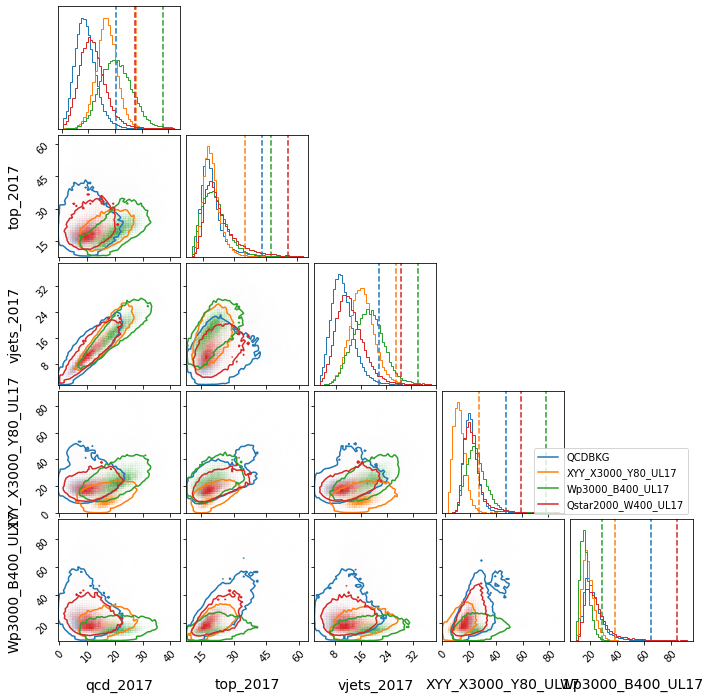

In [144]:
sig_axes = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17']
bkg_axes = ['qcd_{0}'.format(year),'top_{0}'.format(year),'vjets_{0}'.format(year)]
sigs = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
outDir = makeQuakSpace(bkg_axes,sig_axes,baseDir)
makeCornerPlots(outDir,bkg_axes,sig_axes,sigs)

[[0.7020195007324219, 41.999744434356664], [9.518244910240172, 75.47536231994634], [2.6666025161743168, 40.12103462219248], [2.4902987957000735, 87.81270164489734], [7.043717575073242, 62.775835666656434]]


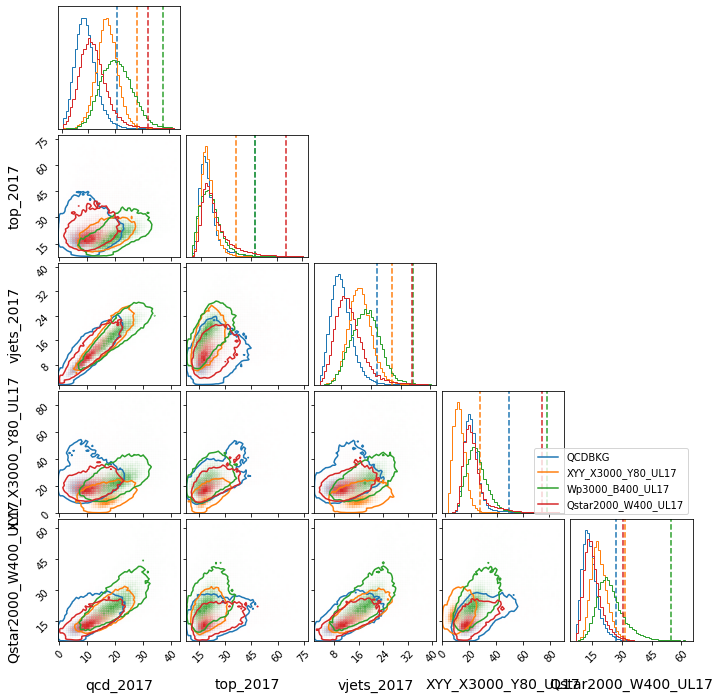

In [145]:
sig_axes = ['XYY_X3000_Y80_UL17','Qstar2000_W400_UL17']
bkg_axes = ['qcd_{0}'.format(year),'top_{0}'.format(year),'vjets_{0}'.format(year)]
sigs = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
outDir = makeQuakSpace(bkg_axes,sig_axes,baseDir)
makeCornerPlots(outDir,bkg_axes,sig_axes,sigs)

[[0.7001220226287842, 47.55286273956321], [9.533277893066407, 73.71201210022024], [2.6635100078582763, 44.47471427917506], [9.645160818099976, 92.47318286895751], [7.0421232938766485, 69.5097782135011]]


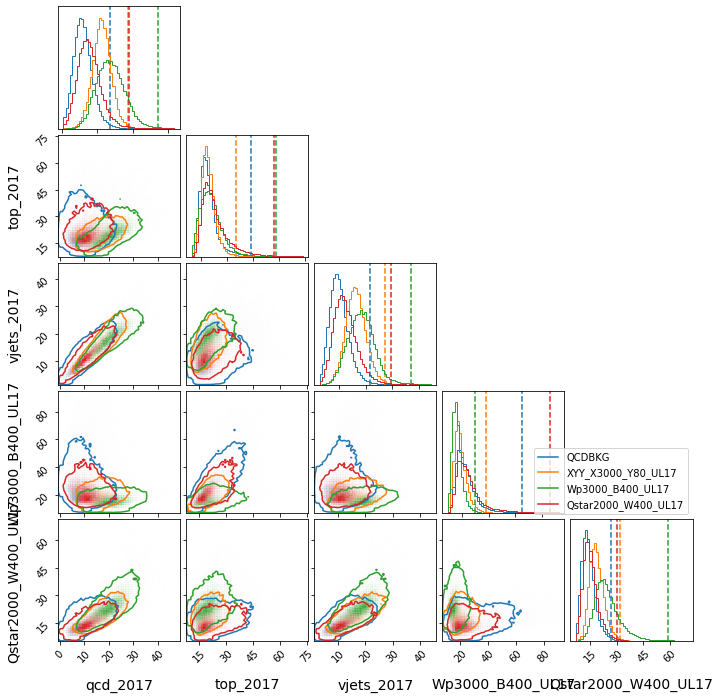

In [146]:
sig_axes = ['Wp3000_B400_UL17','Qstar2000_W400_UL17']
bkg_axes = ['qcd_{0}'.format(year),'top_{0}'.format(year),'vjets_{0}'.format(year)]
sigs = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
outDir = makeQuakSpace(bkg_axes,sig_axes,baseDir)
makeCornerPlots(outDir,bkg_axes,sig_axes,sigs)

[[0.6998886108398437, 41.98632164001463], [9.518181324005127, 62.672859992980996], [2.663370771408081, 38.04635124206541], [2.485521583557129, 87.76628723144525], [9.640319728851319, 92.13084495544433], [7.0421175861358645, 62.776954269409075]]


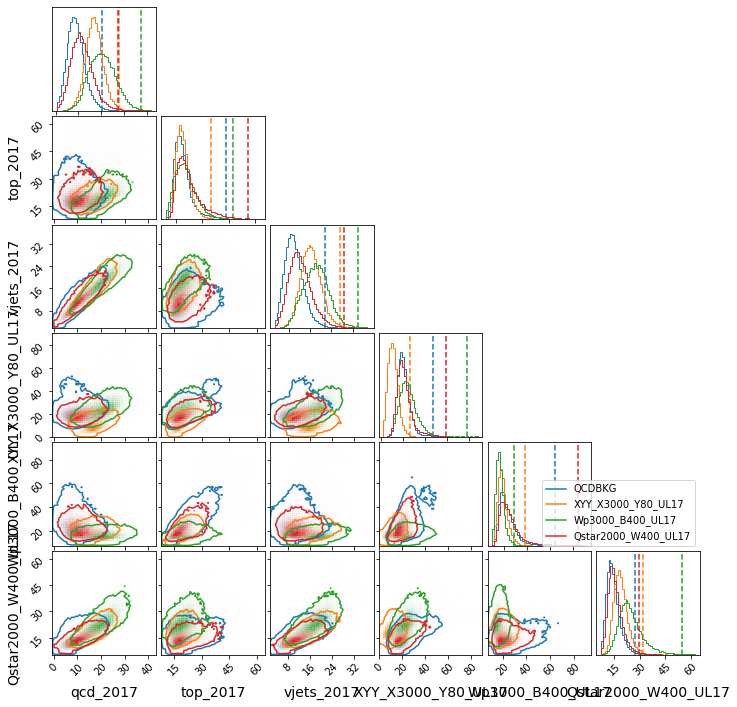

In [147]:
sig_axes = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
bkg_axes = ['qcd_{0}'.format(year),'top_{0}'.format(year),'vjets_{0}'.format(year)]
sigs = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
outDir = makeQuakSpace(bkg_axes,sig_axes,baseDir)
makeCornerPlots(outDir,bkg_axes,sig_axes,sigs)

# Other tests

(-30.0, 50.0)

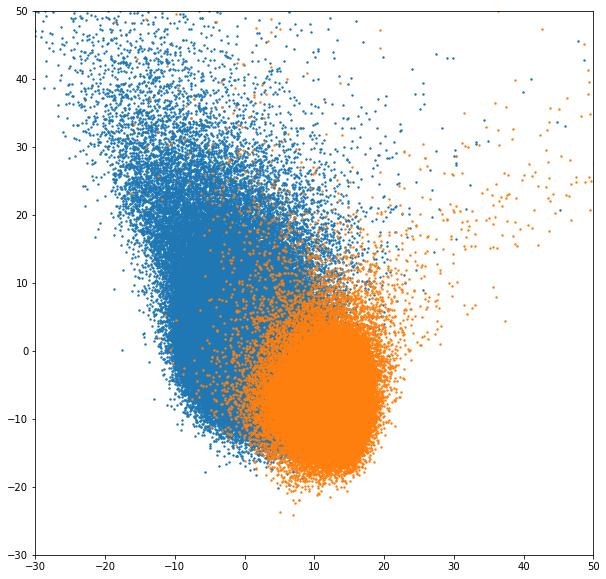

In [9]:
outDir = "evaluations/dataSB/quakSpaces/XYY"
fnb = 'evaluations/dataSB/quakSpaces/dataSB-XYY_X3000_Y80_UL17/eval_QCDBKG_15.h5'
fns = 'evaluations/dataSB/quakSpaces/dataSB-XYY_X3000_Y80_UL17/eval_XYY_X3000_Y80_UL17.h5'

fb = h5py.File(fnb,"r")
fs = h5py.File(fns,"r")

plt.figure(figsize=(10,10))
plt.scatter(fb['dataSB'][()],fb['XYY_X3000_Y80_UL17'][()],s=2)
plt.scatter(fs['dataSB'][()],fs['XYY_X3000_Y80_UL17'][()],s=2)
plt.xlim([-30,50])
plt.ylim([-30,50])

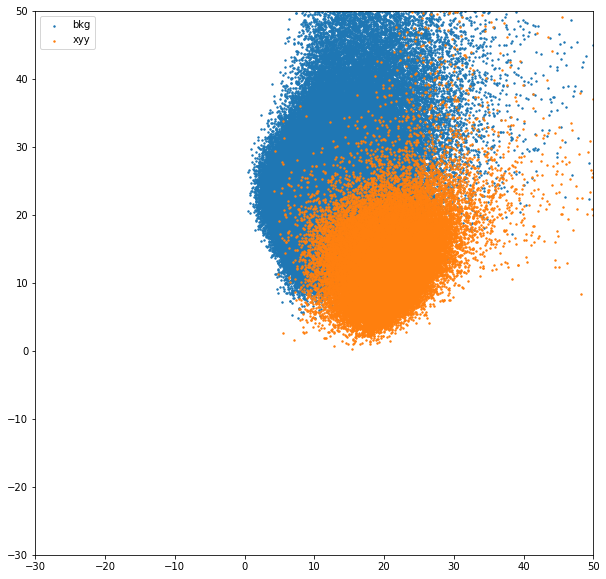

In [2]:
fnb = 'evaluations/dataSB/nominal/eval_QCDBKG_15.h5'
fns = 'evaluations/dataSB/nominal/eval_XYY_X3000_Y80_UL17.h5'

fb = h5py.File(fnb,"r")
fs = h5py.File(fns,"r")

plt.figure(figsize=(10,10))
plt.scatter(fb['dataSB'][()],fb['XYY_X3000_Y80_UL17'][()],s=2,label='bkg')
plt.scatter(fs['dataSB'][()],fs['XYY_X3000_Y80_UL17'][()],s=2,label='xyy')
plt.xlim([-30,50])
plt.ylim([-30,50])
plt.legend(loc='best')

(-30.0, 50.0)

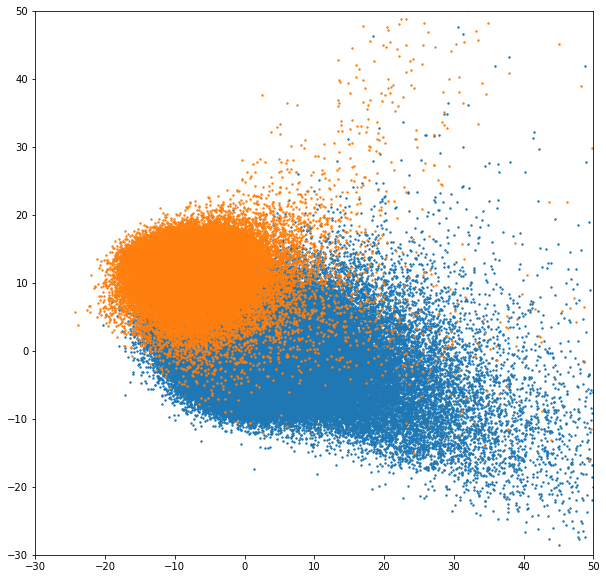

In [4]:
from sklearn.decomposition import PCA

bdat = np.concatenate([fb['mass'][()][:,np.newaxis],fb['dataSB'][()][:,np.newaxis],fb['XYY_X3000_Y80_UL17'][()][:,np.newaxis]],axis=1)
sdat = np.concatenate([fs['mass'][()][:,np.newaxis],fs['dataSB'][()][:,np.newaxis],fs['XYY_X3000_Y80_UL17'][()][:,np.newaxis]],axis=1)

pca = PCA()
pca.fit(bdat)

bt = pca.transform(bdat)
st = pca.transform(sdat)

plt.figure(figsize=(10,10))
plt.scatter(bt[:,1],bt[:,2],s=2)
plt.scatter(st[:,1],st[:,2],s=2)
plt.xlim([-30,50])
plt.ylim([-30,50])